In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Implementation of MCP Neuron for AND and OR Function.

In [1]:
def MCP_Neurons_AND(X1, X2, T):
  """
  This functions implements basic AND operations with MCP Neuron for two inputs.
  Arguments:
  Inputs:
  X1 (1 nd array): An array of binary values.
  X2 (1 nd array): An array of binary values.
  Output:
  state_neuron(1D-list): An state of neuron 1 0r 0 for the particular inputs.
  """
  assert len(X1) == len(X2)

  state_neuron = []

  # Element-wise addition and threshold check
  for i in range(len(X1)):
      total = X1[i] + X2[i]

      if total >= T:
          state_neuron.append(1)
      else:
          state_neuron.append(0)

  return state_neuron

In [2]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value

# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)

# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")


Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [3]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements OR operation using MCP Neuron.

    Arguments:
    X1 (1D array): First input (binary values)
    X2 (1D array): Second input (binary values)
    T (int): Threshold value

    Returns:
    state_neuron (list): Output of neuron (0 or 1)
    """

    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        total = X1[i] + X2[i]

        if total >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [4]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)

# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")


Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


# Implementation for 0 Vs. 1 Classification.

## Step 1: Load the Dataset

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/AI&ML/mnist_0_and_1.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels, features
y = df_0_1["label"].values  # Labels (0 or 1) , target labels

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


### Viewing the Dataset.

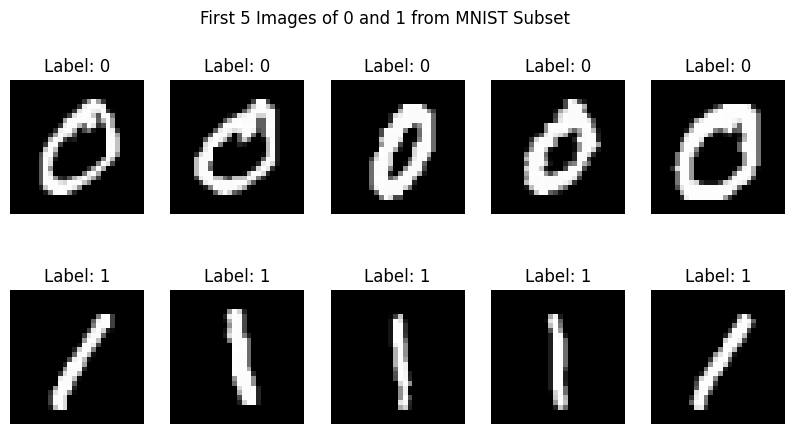

In [10]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

## Step - 2 - Initializing the Weights:

In [11]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

## Step - 3 - Make a Decision function:

In [12]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all

## Step - 3 - Implement the Perceptron Learning Algorithm

In [13]:
import numpy as np

def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (n_samples, n_features)
    - y: Labels (n_samples,)
    - weights: Initial weights (n_features,)
    - bias: Initial bias (scalar)
    - learning_rate: Learning rate (default 0.1)
    - epochs: Number of iterations to train the model (default 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Final accuracy on the training set
    """

    n_samples = X.shape[0]

    for epoch in range(1, epochs + 1):
        total_correct = 0

        for i in range(n_samples):
            # Linear output
            linear_output = np.dot(X[i], weights) + bias

            # Step activation function
            y_pred = 1 if linear_output >= 0 else 0

            # Update weights and bias if prediction is wrong
            error = y[i] - y_pred
            if error != 0:
                weights += learning_rate * error * X[i]
                bias += learning_rate * error
            else:
                total_correct += 1

        # Print accuracy after each epoch
        accuracy_epoch = total_correct / n_samples
        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch}: Accuracy = {accuracy_epoch:.4f}")

    # Final accuracy
    accuracy = total_correct / n_samples
    return weights, bias, accuracy

## Training the Perceptron

In [14]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

Epoch 1: Accuracy = 0.9967
Epoch 10: Accuracy = 0.9992
Epoch 20: Accuracy = 1.0000
Epoch 30: Accuracy = 1.0000
Epoch 40: Accuracy = 1.0000
Epoch 50: Accuracy = 1.0000
Epoch 60: Accuracy = 1.0000
Epoch 70: Accuracy = 1.0000
Epoch 80: Accuracy = 1.0000
Epoch 90: Accuracy = 1.0000
Epoch 100: Accuracy = 1.0000
The Final Accuracy is:  1.0


## Step 5: Visualize Misclassified Images

In [15]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


---
# Task 3: Perceptron Algorithm for 3 vs 5 Classification


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the 3 vs 5 dataset
df_3_5 = pd.read_csv("/content/drive/MyDrive/AI&ML/mnist_3_and_5.csv")

# Extract features and labels
X_35 = df_3_5.drop(columns=["label"]).values   # 784 pixel features
y_35_raw = df_3_5["label"].values              # Labels: 3 or 5

# Convert labels to binary: 3 -> 0, 5 -> 1  (perceptron needs {0,1})
y_35 = np.where(y_35_raw == 5, 1, 0)

print("Feature matrix shape:", X_35.shape)
print("Label vector shape:", y_35.shape)
print("Class distribution - 3s:", np.sum(y_35 == 0), "| 5s:", np.sum(y_35 == 1))

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)
Class distribution - 3s: 1484 | 5s: 1257


## Step 2: Visualize the 3 vs 5 Dataset

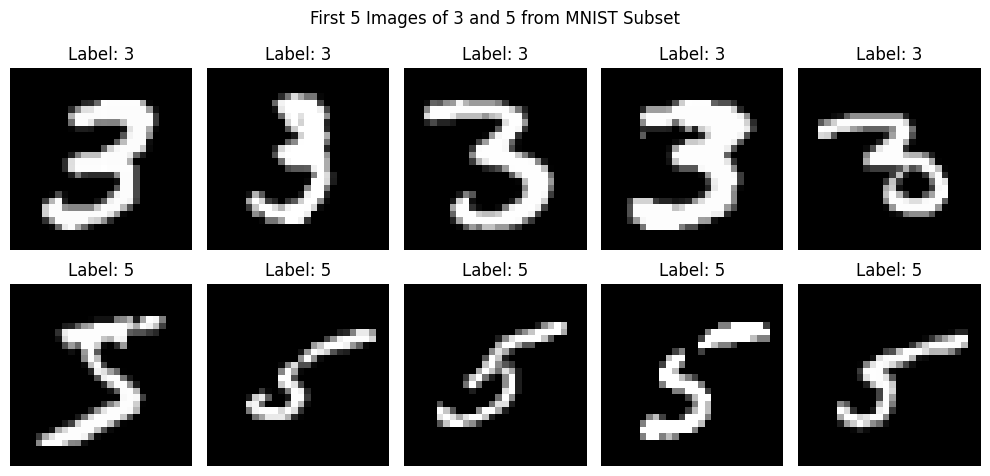

In [18]:
# Separate images by class
images_3 = X_35[y_35 == 0]  # digit 3 (mapped to label 0)
images_5 = X_35[y_35 == 1]  # digit 5 (mapped to label 1)

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(5):
    axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 3")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 5")
    axes[1, i].axis("off")

plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
plt.tight_layout()
plt.show()

## Step 3: Initialize Weights and Bias for 3 vs 5

In [19]:
# Initialize weights and bias to zero
weights_35 = np.zeros(X_35.shape[1])  # 784 weights
bias_35 = 0
learning_rate_35 = 0.1
epochs_35 = 100

print(f"Weights shape: {weights_35.shape}")
print(f"Initial bias: {bias_35}")

Weights shape: (784,)
Initial bias: 0


## Step 4: Train the Perceptron on 3 vs 5

In [20]:
weights_35, bias_35, accuracy_35 = train_perceptron(
    X_35, y_35, weights_35, bias_35,
    learning_rate=learning_rate_35,
    epochs=epochs_35
)

print(f"\nFinal Training Accuracy (3 vs 5): {accuracy_35:.4f}")

Epoch 1: Accuracy = 0.9157
Epoch 10: Accuracy = 0.9566
Epoch 20: Accuracy = 0.9661
Epoch 30: Accuracy = 0.9726
Epoch 40: Accuracy = 0.9719
Epoch 50: Accuracy = 0.9788
Epoch 60: Accuracy = 0.9759
Epoch 70: Accuracy = 0.9792
Epoch 80: Accuracy = 0.9792
Epoch 90: Accuracy = 0.9843
Epoch 100: Accuracy = 0.9858

Final Training Accuracy (3 vs 5): 0.9858


## Step 5: Evaluate and Visualize Misclassified Images (3 vs 5)

Final Accuracy (3 vs 5): 0.9869
Total misclassified: 36 out of 2741 samples


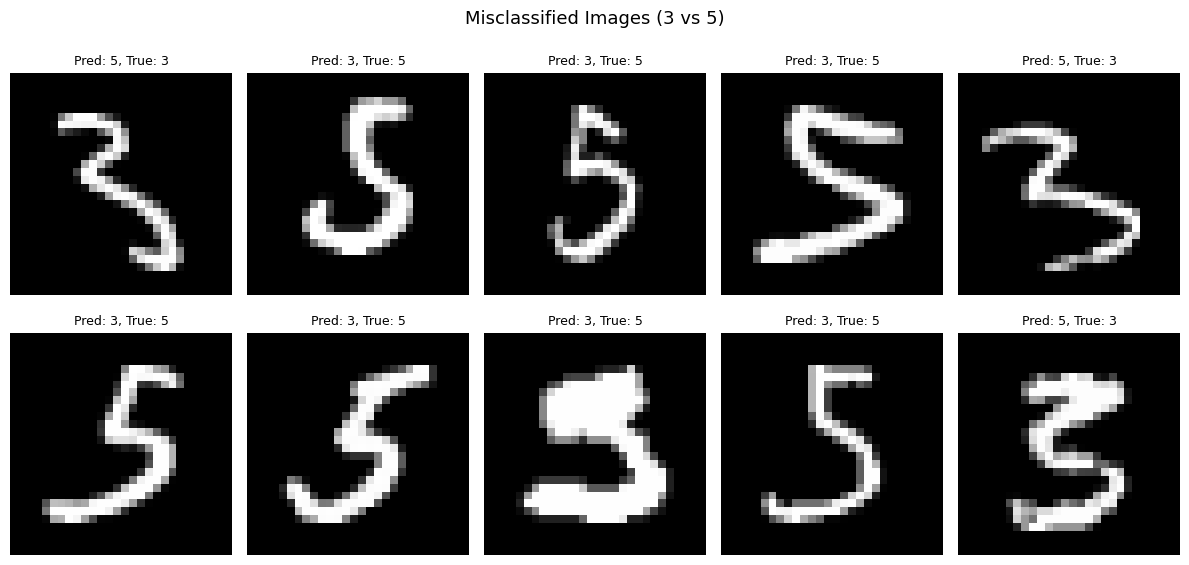

In [21]:
# Get predictions for all 3 vs 5 data
predictions_35 = np.dot(X_35, weights_35) + bias_35
y_pred_35 = np.where(predictions_35 >= 0, 1, 0)

# Map binary predictions back to original labels for display
y_pred_35_display = np.where(y_pred_35 == 1, 5, 3)
y_true_35_display = np.where(y_35 == 1, 5, 3)

# Calculate final accuracy
final_accuracy_35 = np.mean(y_pred_35 == y_35)
print(f"Final Accuracy (3 vs 5): {final_accuracy_35:.4f}")
print(f"Total misclassified: {np.sum(y_pred_35 != y_35)} out of {len(y_35)} samples")

# Visualize misclassified images
misclassified_idx_35 = np.where(y_pred_35 != y_35)[0]

if len(misclassified_idx_35) > 0:
    n_show = min(10, len(misclassified_idx_35))
    rows = (n_show + 4) // 5
    fig, axes = plt.subplots(rows, 5, figsize=(12, rows * 3))
    axes = axes.flat
    for ax, idx in zip(axes, misclassified_idx_35[:n_show]):
        ax.imshow(X_35[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred_35_display[idx]}, True: {y_true_35_display[idx]}", fontsize=9)
        ax.axis("off")
    # Turn off any empty axes
    for ax in axes:
        ax.axis("off")
    plt.suptitle("Misclassified Images (3 vs 5)", fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("All images were correctly classified!")

**Why is 3 vs 5 harder?**
- Digits 3 and 5 share very similar visual structure as both have curves, similar height, and overlapping pixel activations in the middle regions.
- The pixel-level differences are subtle and vary across handwriting styles.
- The two classes are not cleanly linearly separable which is a fundamental limitation of the perceptron.


**Perceptron Limitation:**
This demonstrates the core limitation of the single-layer perceptron: it can only learn linearly separable patterns. For more complex classification problems (like 3 vs 5), we need more powerful models such as multi-layer perceptrons (MLPs) or deep neural networks that can learn non-linear decision boundaries through hidden layers and non-linear activation functions.